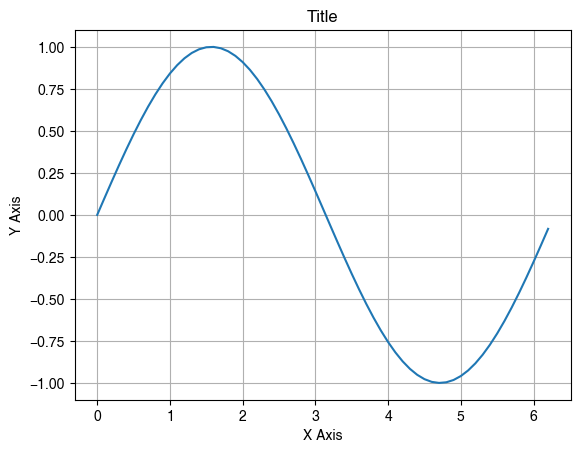

In [2]:
import matplotlib.pyplot as plt
# 通过plt进行交互式绘图，绘制折线图
import numpy as np
# 生成数据
x = np.arange(0, 2 * np.pi, 0.1)
y = np.sin(x)
plt.plot(x, y)
# 设置图名，坐标轴名称，图内格网
plt.title('Title')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.grid(True)
# 调用show()方法进行图像展示
plt.show()

In [4]:
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure

fig = Figure()
FigureCanvas(fig)
ax = fig.add_subplot(111)  # add_subplot()方法中的111表示的是1×1格网，第1个子图
ax.plot(x, y)
ax.set_title('Title')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.grid(True)
fig.savefig('sin.png', dpi=120)

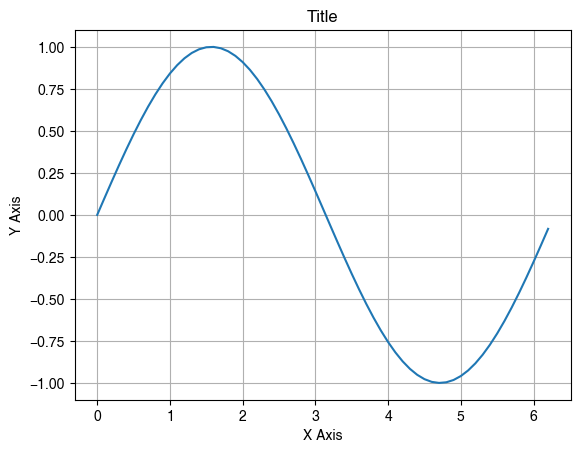

In [5]:
import matplotlib.pyplot as plt

ax = plt.subplot(111)
ax.plot(x, y)
ax.set_title('Title')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.grid(True)
plt.show()

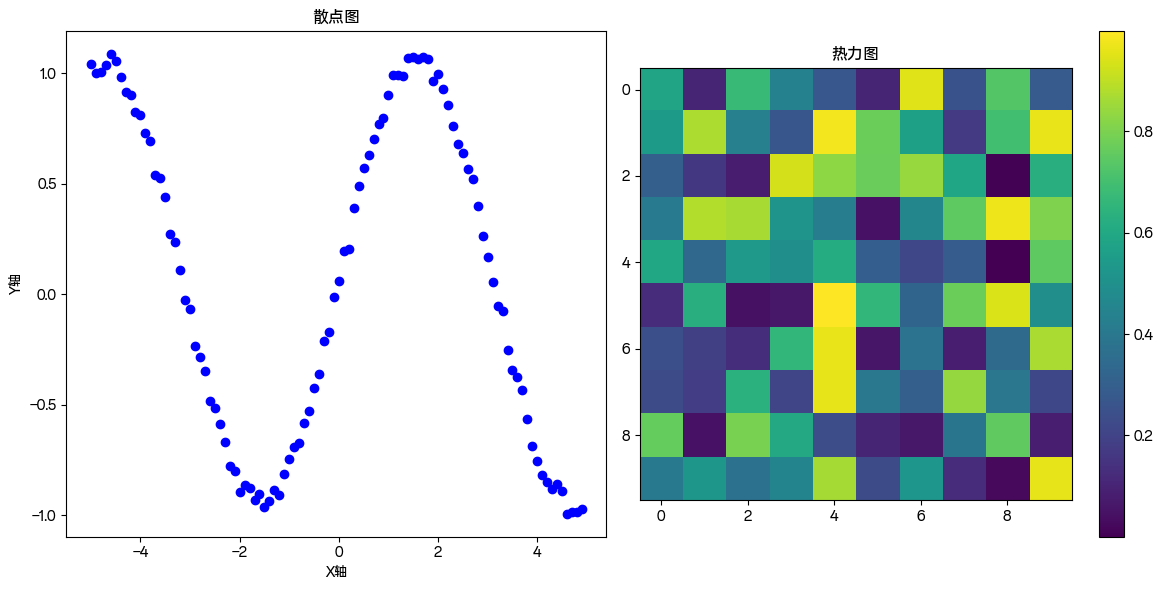

In [12]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# 默认为英文字体，中文字符无法正确显示，所以需要手动设置一下中文字体
# 我这里设置为OPPO Sans，当然你也可以设置为自己喜欢的而且电脑上已经安装了的字体
matplotlib.rc("font",family='OPPO Sans')

# 随机生成X和Y序列
x = np.arange(-5, 5, 0.1)
y = np.sin(x) + np.random.rand(x.size) * 0.1
# 随机生成一个10X10的矩阵
data = np.random.rand(10, 10)

# 创建包含两个子图的Figure，并指定输出图像大小
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# 通过X和Y坐标绘制散点图，并设置标题和坐标轴标签
axs[0].scatter(x, y, c='blue', marker='o')
axs[0].set_title('散点图')
axs[0].set_xlabel('X轴')
axs[0].set_ylabel('Y轴')

# 左边的子图绘制一个热力图，使用内置的viridis做色彩填充
cax = axs[1].imshow(data, cmap='viridis', interpolation='nearest')
fig.colorbar(cax, ax=axs[1])
axs[1].set_title('热力图')

# 自动调整图中整体布局并展示
plt.tight_layout()
# 将图片输出并保存为PDF，当然你也可以保存为其他格式
plt.savefig('subplots.pdf', dpi=300)
plt.show()

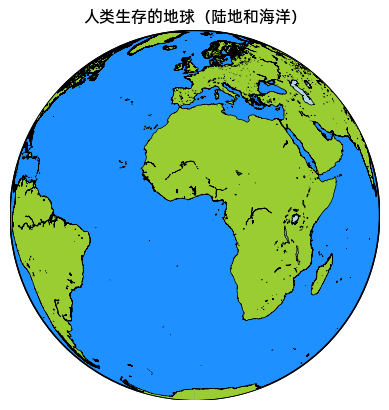

In [6]:
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# 设置中文字体
matplotlib.rc("font",family='OPPO Sans')
# lon_0, lat_0 是投影中心经纬度
# resolution = 'i'表示中分辨率
m = Basemap(projection='ortho', lon_0=0, lat_0=0, resolution='h')
m.drawcoastlines(linewidth=0.5) # 绘制海岸线
# m.drawcountries() # 绘制国界
m.drawmapboundary(fill_color='dodgerblue')  # 给海洋填充浅蓝色
m.fillcontinents(color='yellowgreen',lake_color='lightblue')  # 给陆地填充浅绿色
plt.title("人类生存的地球（陆地和海洋）")
plt.savefig('/Users/tanzhenyu/Desktop/图2.9.png', dpi=600)
plt.show()

求解方程组：
$$
\begin{cases}
7x + 2y = 8 \\
4x + 5y = 10
\end{cases}
$$

In [6]:
from scipy import linalg
import numpy as np

# 方程系数
a = np.array([[7, 2], [4, 5]])
b = np.array([8, 10])

# 使用solve()函数求解线性方程组
res = linalg.solve(a, b)
print(res)

# 我们也可以通过求矩阵的逆来进行方程求解
# 注意这里要将np.ndarray转为np.mat进行矩阵运算
# np.mat(b).H为矩阵b的转置
res = np.mat(linalg.inv(a)) * np.mat(b).H
print(res)

[0.74074074 1.40740741]
[[0.74074074]
 [1.40740741]]


要满足Delaunay三角剖分的定义，必须符合两个重要的准则：
1、空圆特性：Delaunay三角网是唯一的（任意四点不能共圆），在Delaunay三角形网中任一三角形的外接圆范围内不会有其它点存在。
2、最大化最小角特性：在散点集可能形成的三角剖分中，Delaunay三角剖分所形成的三角形的最小角最大。从这个意义上讲，Delaunay三角网是“最接近于规则化的“的三角网。

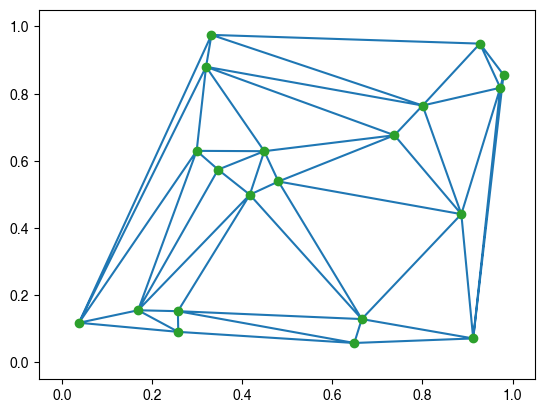

In [9]:
# 构建Delaunay三角网
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

points = np.random.rand(20, 2) # 随机生成20个2维点
tri = Delaunay(points)

plt.triplot(points[:, 0], points[:, 1], tri.simplices) # 绘制三角格网
plt.plot(points[:,0], points[:,1], 'o') # 绘制10这十个离散点

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.show()

In [15]:
# 最简单的一个线性回归案例
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 准备训练样本数据，构造一个x和y的关系，并给y添加噪声
x = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
param = np.array([1, 2])
y = np.dot(x, param) + np.random.rand(4)

# 对输入数据进行标准化，然后建立模型并进行训练
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(x, y)

# 进行模型精度评价（R2）
print(f'模型的决定系数为：{model.score(x, y):.2f}')

# 进行预测
ins = np.array([[3, 5]])
pred = model.predict(ins)
print(f'输入数据{ins}, 得到预测结果为{pred}')
print(f'真实结果为{np.dot(ins, param)}')

模型的决定系数为：0.99
输入数据[[3 5]], 得到预测结果为[13.77985902]
真实结果为[13]


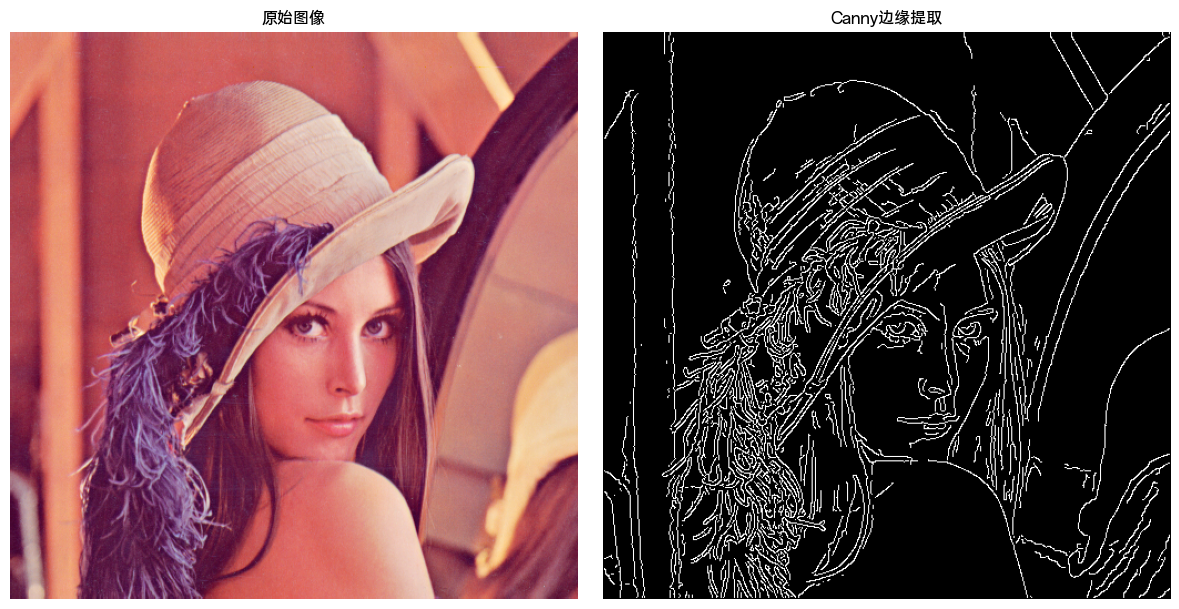

In [22]:
import matplotlib
import matplotlib.pyplot as plt
from skimage import io, feature
from skimage.color import rgb2gray

matplotlib.rc("font",family='OPPO Sans')

# 加载一张计算机视觉领域常用的Lenna图像
image = io.imread('http://www.lenna.org/lena_std.tif')
# 将RGB图像转为灰度图像
grayscale = rgb2gray(image)
# 提取人物轮廓
profile = feature.canny(grayscale, sigma=1.0)

# 通过Matplotlib绘制两张图像进行展示
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title('原始图像')
# 不显示坐标轴
ax[0].axis('off')
ax[1].imshow(profile, plt.cm.grey)
ax[1].set_title('Canny边缘提取')
ax[1].axis('off')

plt.tight_layout()
plt.show()

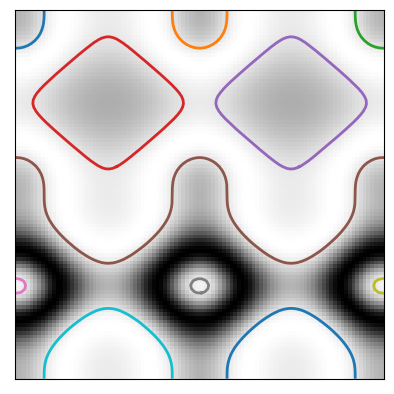

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import measure

# 使用np.ogrid()函数构造一个二维数组
# 复数步长的设置是通过j进行设置的，如100j。复数前表示的是，用几个数值来等分整个区间。
x, y = np.ogrid[-np.pi: np.pi: 100j, -np.pi: np.pi: 100j]
r = np.sin(np.exp((np.sin(x) ** 3 + np.cos(y) ** 2)))

# 通过find_contours()函数寻找等高线，level参数指示了在图像中查找等高线的级别值
# 返回值为一个list，每个list中是等高线的坐标（row, column）
contours = measure.find_contours(r, level=0.8)

# 先以灰度图像显示图像r，然后使用for循环绘制寻找到的等高线
fig, ax = plt.subplots()
ax.imshow(r, cmap=plt.cm.gray)

for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], linewidth=2)
# 隐藏x和y坐标
ax.set_xticks([])
ax.set_yticks([])
plt.show()